In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_phasemax_noise import LogLike
# from loglike_pure_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

# data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
# print(f'SNR (time-max): {data_snr:.4f}')


def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=5s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris1/int_TDI'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.416505  ,  0.163205  ,  0.599625  ,  0.428895  ,  0.918285  ],
        [ 0.41037371,  0.16146142,  0.60439824,  0.42970274,  0.92844674],
        [ 0.42806913,  0.17181654,  0.59633463,  0.43281902,  0.92331018],
        ...,
        [ 1.10716296, -0.01452873,  0.77112184, -0.39970841,  1.53044279],
        [ 0.6289273 ,  0.59970995, -0.07396449, -0.07269439,  0.94513794],
        [-0.21442764, -0.18452035,  0.68055277,  1.25904469,  1.1440998 ]])]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([0.60835375, 0.21502482, 0.63220613, ...,       -inf,       -inf,
              -inf])]

In [7]:
sampler.now_covariances

[array([[ 0.22696171,  0.01757662, -0.02393264, -0.03508664,  0.0140026 ],
        [ 0.01757662,  0.16243959,  0.00522147,  0.02369521,  0.00901413],
        [-0.02393264,  0.00522147,  0.28744029,  0.0011571 ,  0.01476913],
        [-0.03508664,  0.02369521,  0.0011571 ,  0.27323649, -0.00500887],
        [ 0.0140026 ,  0.00901413,  0.01476913, -0.00500887,  0.29547685]])]

In [8]:
np.argmax(logden_list)

368

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.94945358, 0.88479404, 0.67267219, 9.27361124, 0.47424055]])

In [10]:
log_density(maxld_pt1)

array([1.11482389])

In [11]:
log_density([param_true])

array([10.91236408])

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

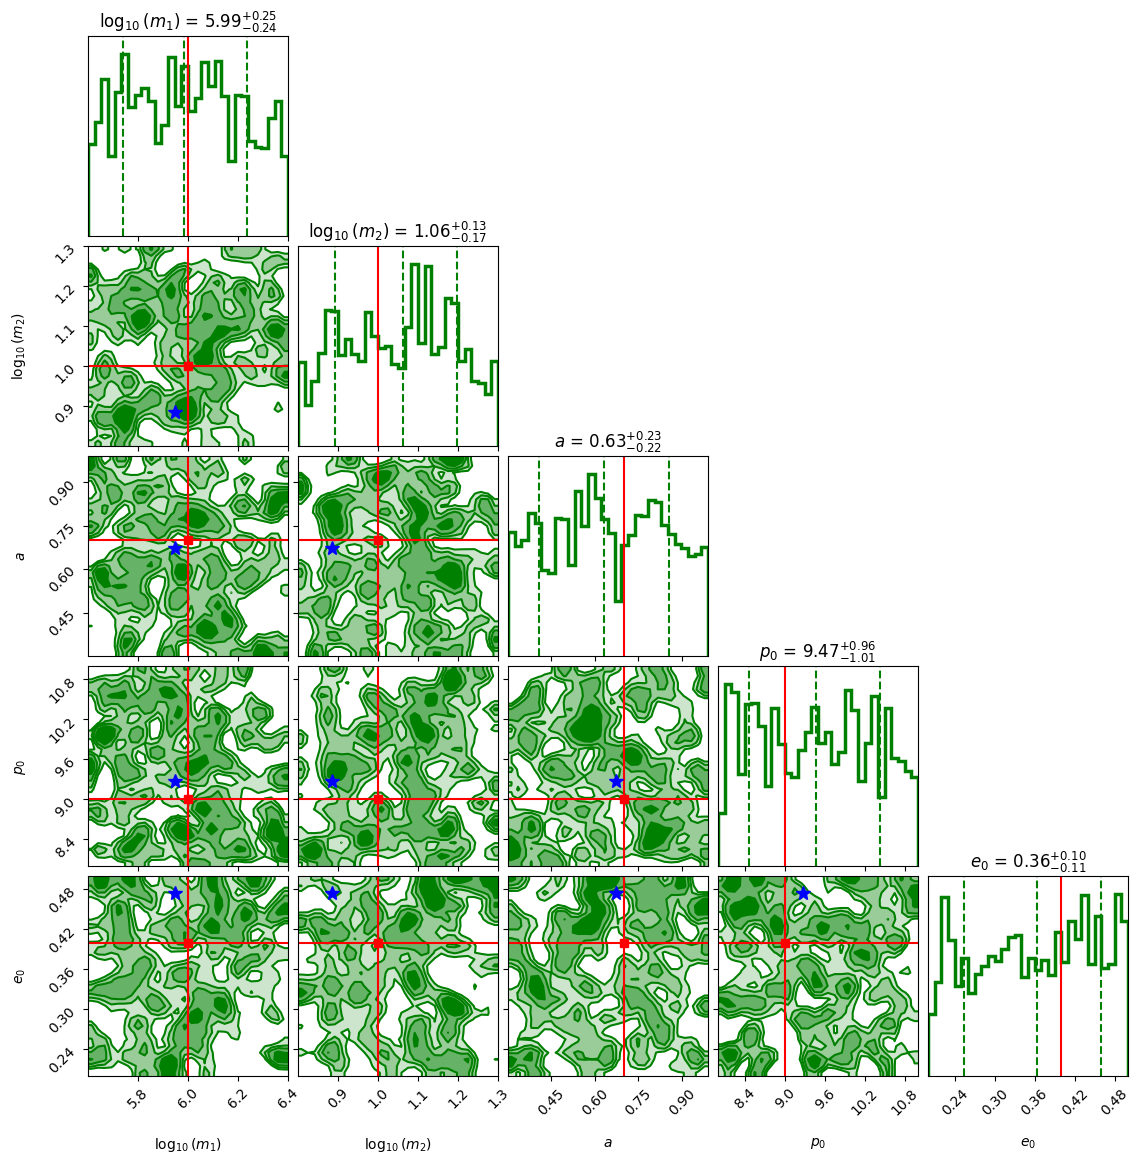

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
np.sort(logden_list)

array([[      -inf,       -inf,       -inf, ..., 0.6827492 , 0.88649707,
        1.11482389]])

In [16]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_idx

array([368, 362, 250, 478,   2, 400,   0, 383, 289, 439])

In [17]:
top10_pts = prior_transform(proc_pt[0][top10_idx])
top10_pts

array([[5.94945358, 0.88479404, 0.67267219, 9.27361124, 0.47424055],
       [5.94158769, 0.86640164, 0.66530791, 9.21705882, 0.47273014],
       [5.95349834, 0.87882526, 0.67179639, 9.309068  , 0.47168412],
       [5.93809804, 0.8612194 , 0.6577836 , 9.15493286, 0.47703304],
       [5.94245531, 0.88590827, 0.71147089, 9.29845705, 0.47699305],
       [5.93632203, 0.871665  , 0.66906721, 9.29768442, 0.47498725],
       [5.933204  , 0.8816025 , 0.71374125, 9.286685  , 0.4754855 ],
       [5.94483221, 0.8731588 , 0.65952586, 9.20904113, 0.47560794],
       [5.96597304, 0.87610812, 0.70663148, 9.12597436, 0.47168069],
       [5.95441624, 0.89739407, 0.70616356, 9.23197597, 0.46955575]])

In [18]:
np.average(top10_pts.T[0])

5.945984047891725

In [19]:
np.average(top10_pts.T[1])

0.8777077077507984

In [20]:
np.average(top10_pts.T[2])

0.6834160360632369

In [21]:
np.average(top10_pts.T[3])

9.240448884509716

In [22]:
np.average(top10_pts.T[4])

0.4739998044871352

In [23]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

In [24]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [25]:
import matplotlib.pyplot as plt

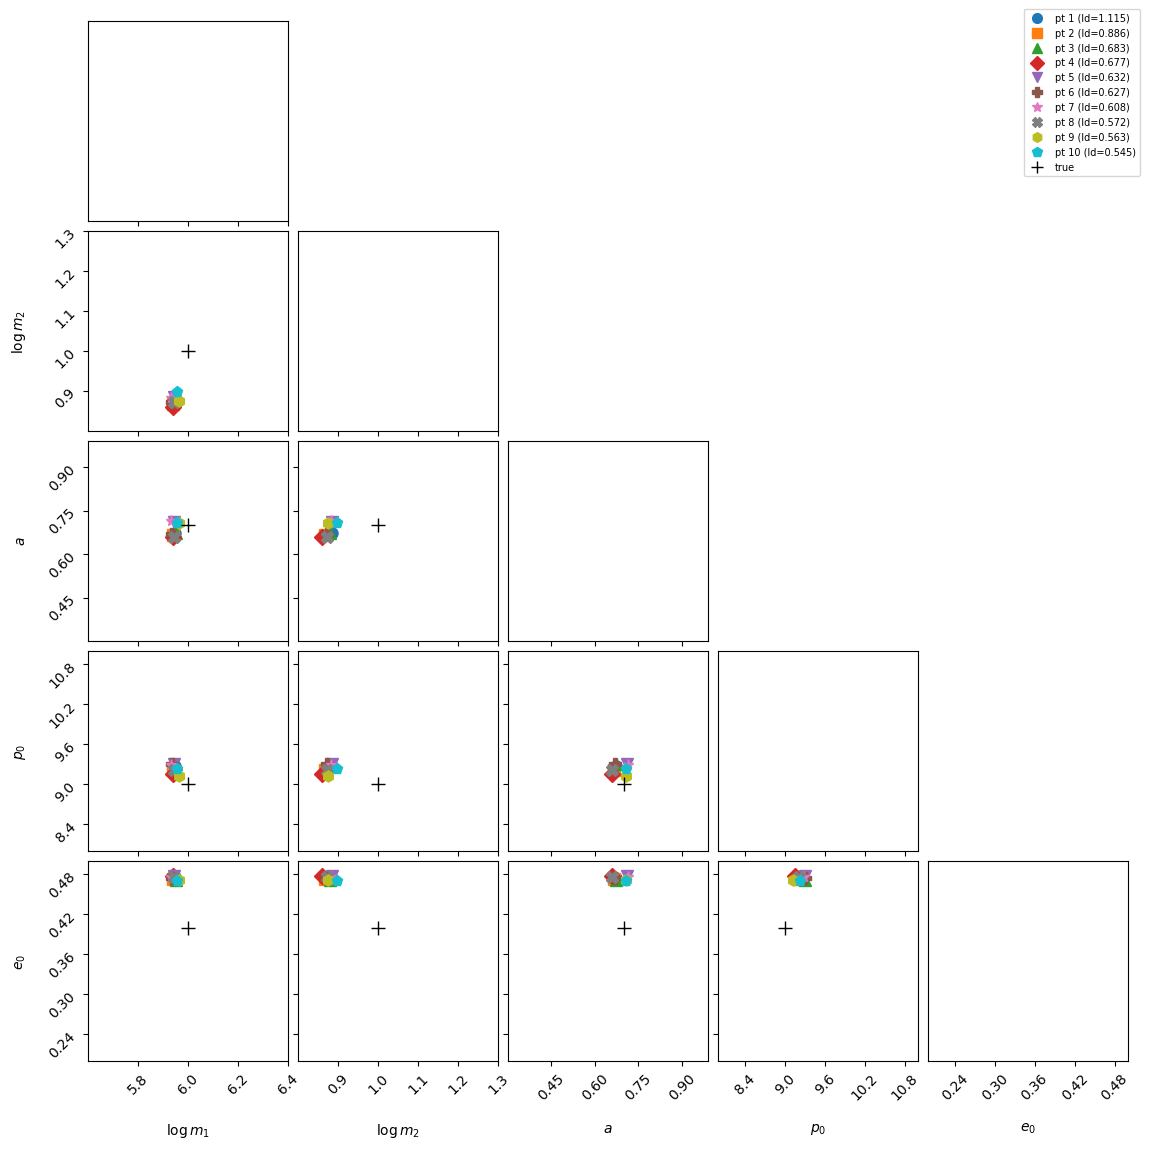

In [26]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [true_params]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

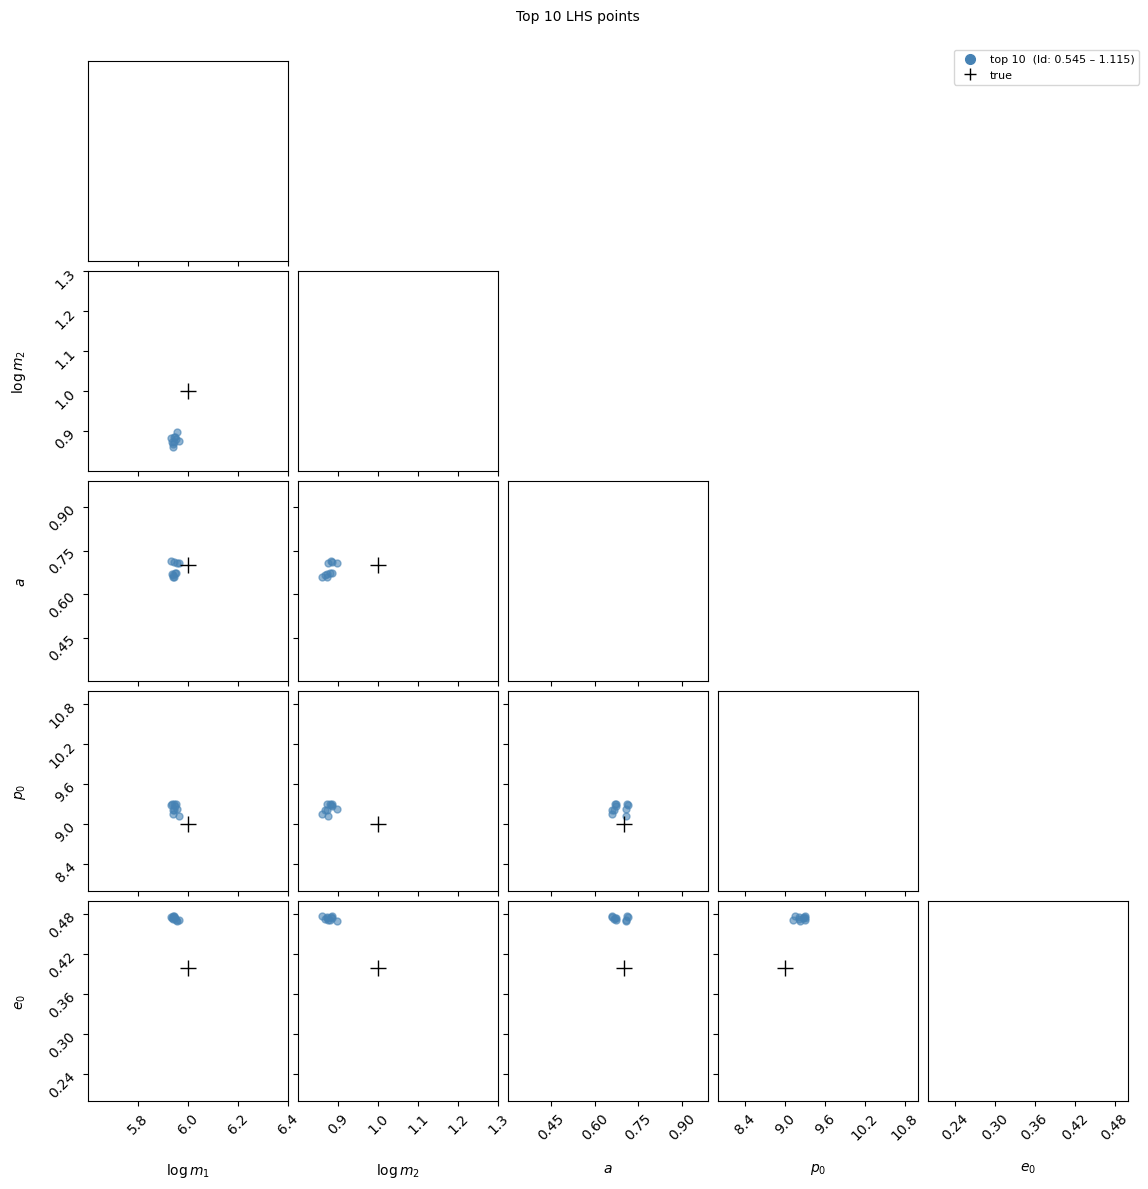

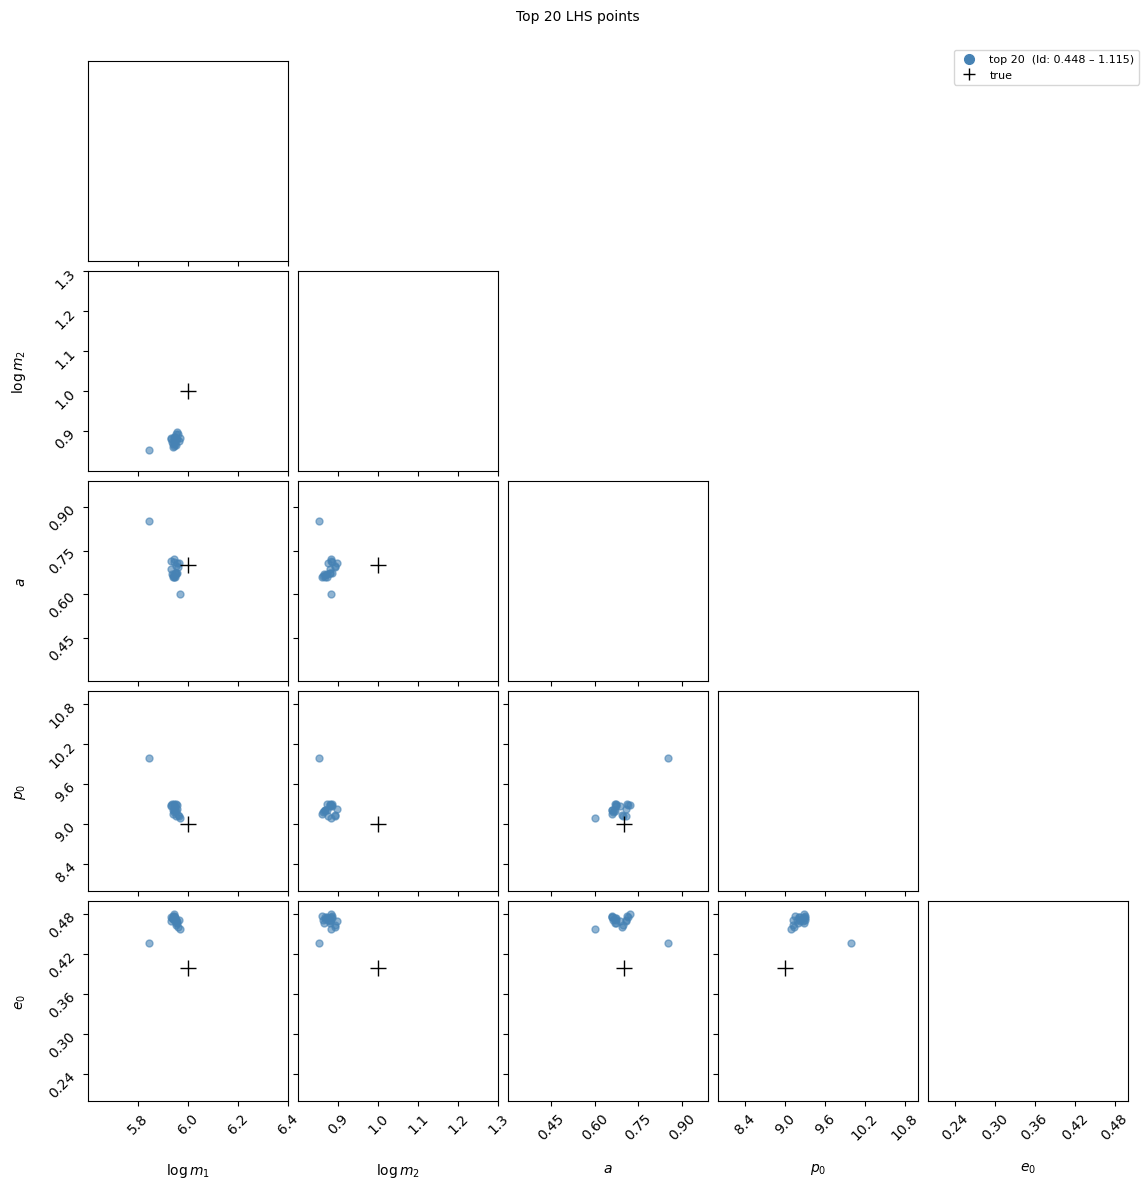

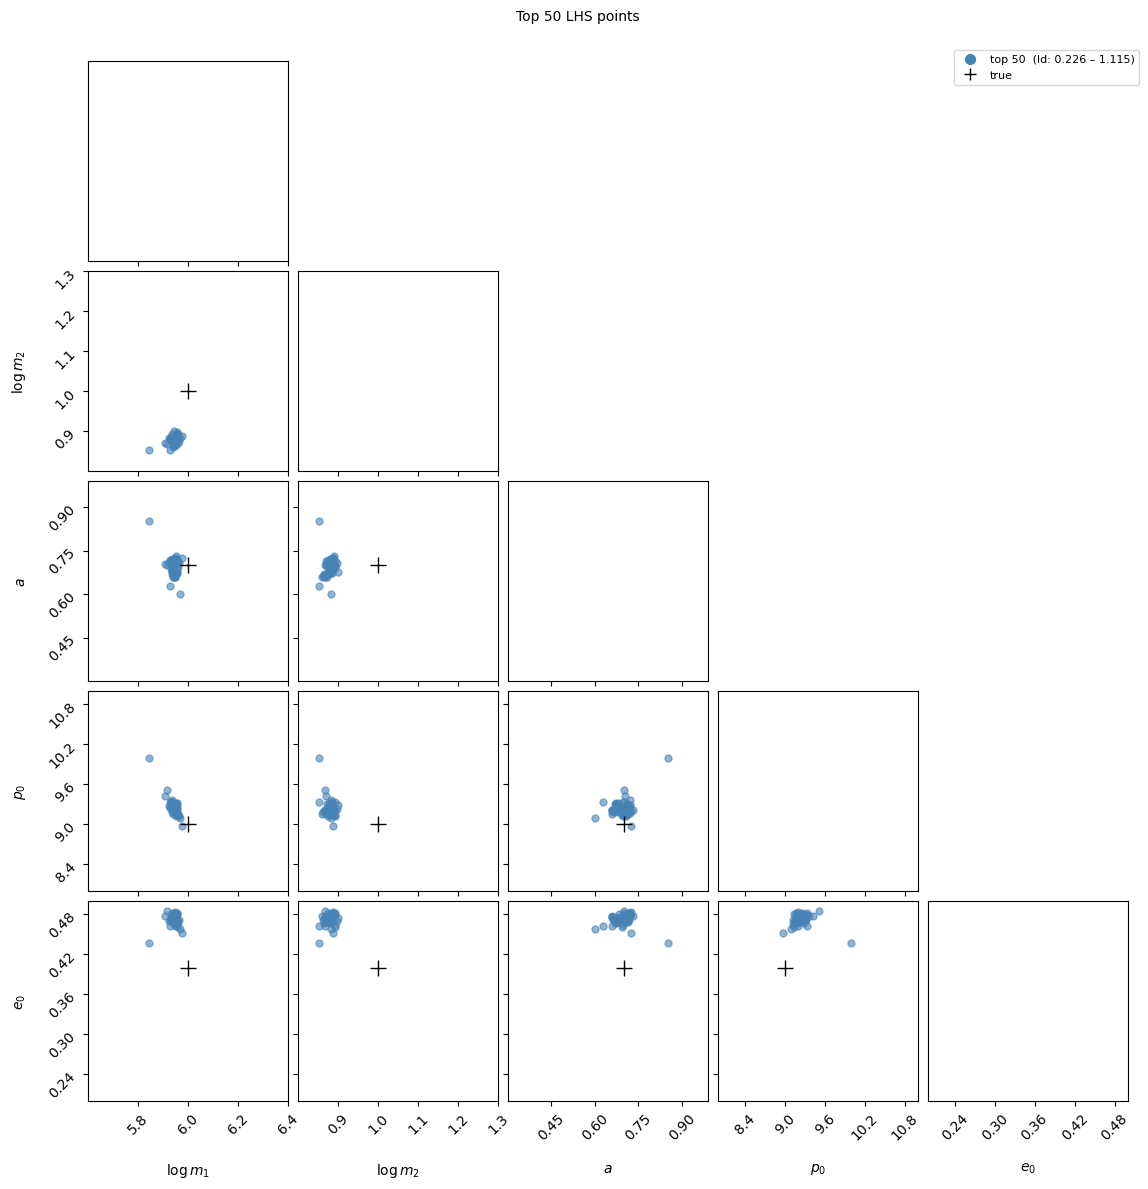

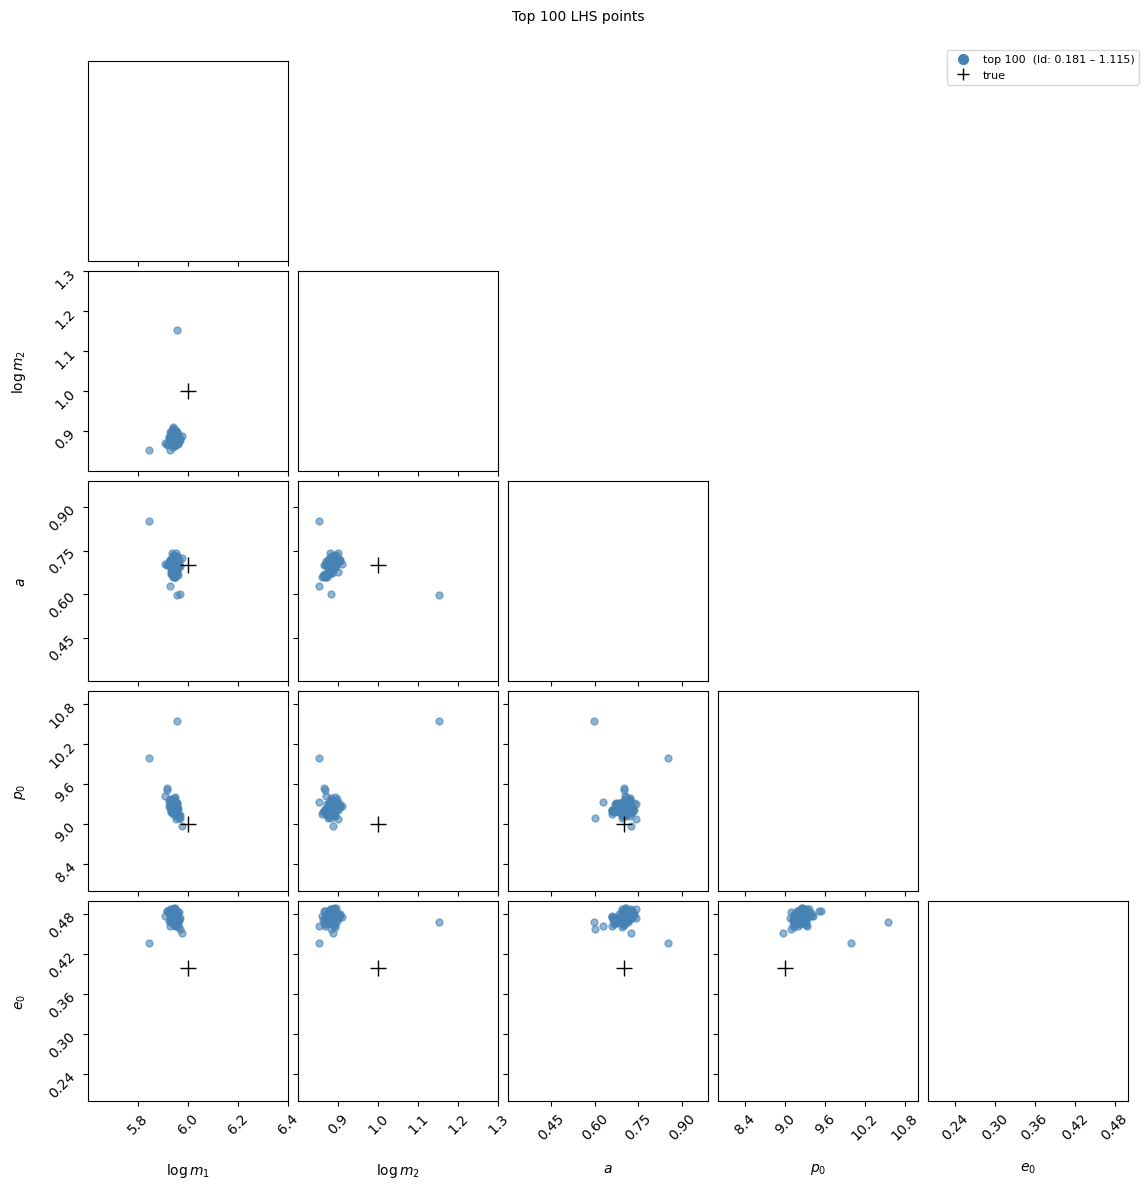

In [27]:
from matplotlib.lines import Line2D

all_logden = np.concatenate(logden_list)
sorted_idx = np.argsort(all_logden).flatten()

def plot_topN(N, color='steelblue', marker='o', ms=5):
    idx = sorted_idx[-N:][::-1]
    pts = prior_transform(proc_pt[0][idx])
    ld_vals = all_logden[idx]

    all_pts = np.vstack([pts, [true_params]])
    fig = corner.corner(all_pts, labels=labels, show_titles=False,
                        plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                        hist_kwargs=dict(alpha=0, lw=0))

    corner.overplot_points(fig, pts, color=color, marker=marker, ms=ms, alpha=0.6)
    corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=12, zorder=10)

    axes_arr = np.array(fig.axes).reshape((ndim, ndim))
    for row in range(ndim):
        for col in range(ndim):
            if col <= row:
                axes_arr[row, col].set_xlim(ranges[col])
            if col < row:
                axes_arr[row, col].set_ylim(ranges[row])

    handles = [
        Line2D([0],[0], color=color, marker=marker, ls='', ms=7,
                label=f'top {N}  (ld: {ld_vals[-1]:.3f} – {ld_vals[0]:.3f})'),
        Line2D([0],[0], color='black', marker='+', ls='', ms=9, label='true'),
    ]
    fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=8)
    fig.suptitle(f'Top {N} LHS points', fontsize=10, y=1.01)
    plt.show()

for N in [10, 20, 50, 100]:
    plot_topN(N)

# connection plot

In [28]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.94945358, 0.88479404, 0.67267219, 9.27361124, 0.47424055]])

In [29]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [30]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [31]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [32]:
logden_theory_proc1

array([ 1.11482389,  1.05482685,  0.98678729,  1.23858737,  1.28757526,
        1.30898605,  1.28513109,  1.30074826,  1.27617127,  1.23730669,
        1.19712198,  1.14778868,  1.07370725,  1.0523129 ,  0.99706146,
        1.042266  ,  0.99825187,  0.99152927,  1.02162595,  1.03928019,
        1.02309435,  1.0597332 ,  1.06715371,  0.96927242,  1.00932603,
        1.0209813 ,  0.89535352,  1.05237277,  1.02130963,  1.15437378,
        1.14205712,  1.23367062,  1.22416068,  1.2803603 ,  1.28029771,
        1.34913242,  1.44067448,  1.57079823,  1.74141401,  1.90450236,
        2.01132664,  1.92508882,  1.3447292 ,  1.9891548 ,  2.36515321,
        2.9391061 ,  4.42261606,  6.98198911, 10.0331504 , 10.91236408])

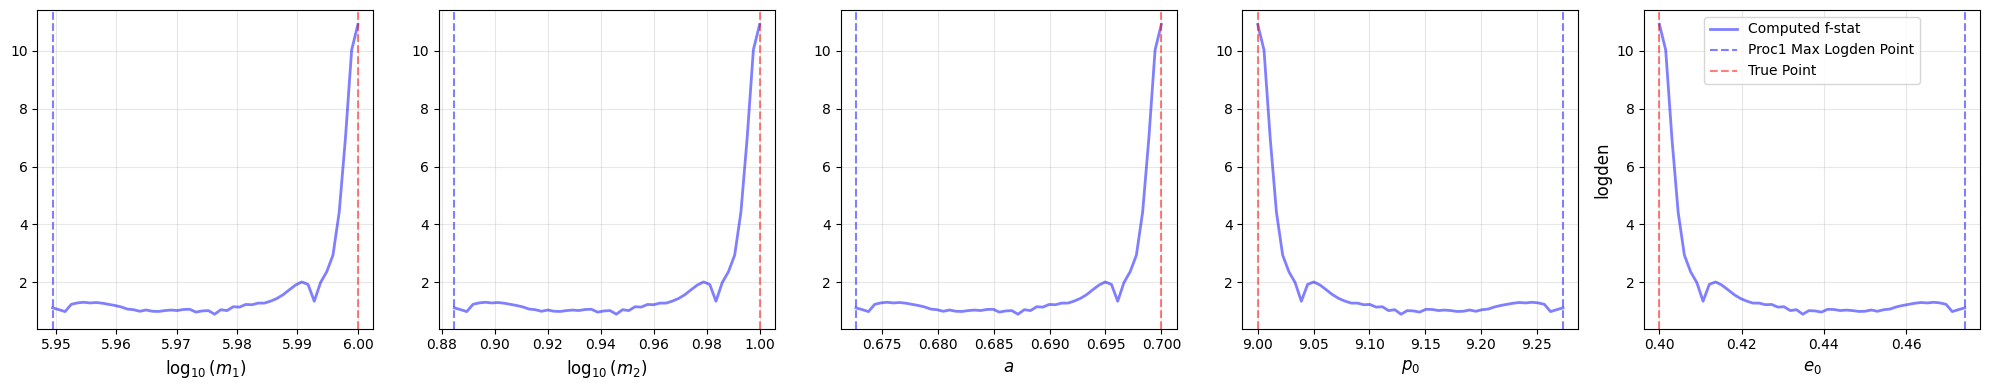

In [33]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [34]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [35]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [36]:
logden_tm = log_density(line_points_logm1.T)


In [37]:
logden_tm

array([          -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf,           -inf,
                 -inf,           -inf,           -inf, 1.37389902e-01,
       2.23680458e-01, 1.82060563e-01, 1.84367288e-01, 1.73307258e-01,
       1.57919202e-01, 1.45072350e-01, 1.46197377e-01, 1.32114648e-01,
      

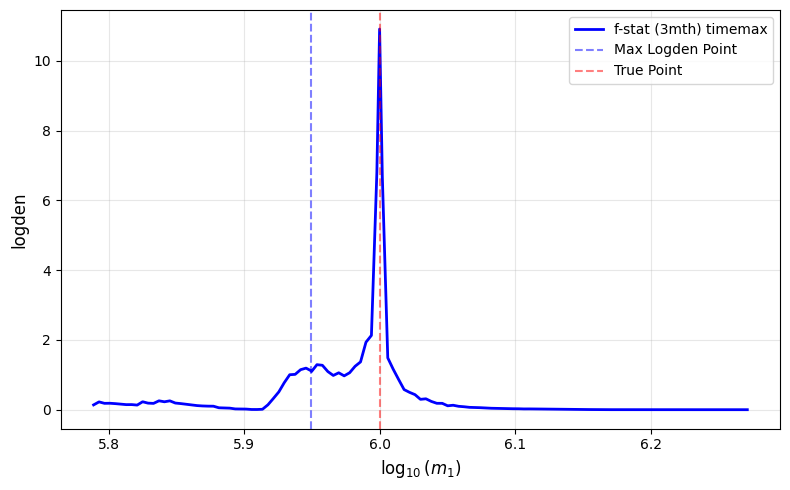

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='f-stat (3mth) timemax')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

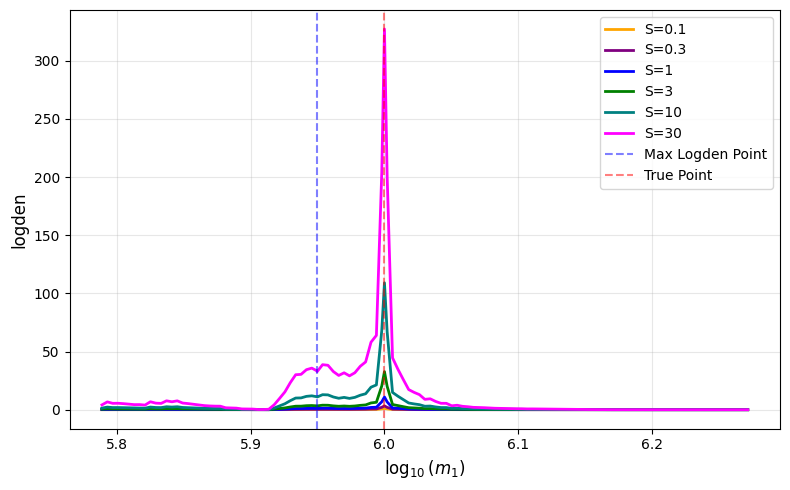

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm*0.1, '-', color='orange', linewidth=2, label='S=0.1')
ax.plot(line_points_logm1[0], logden_tm*0.3, '-', color='purple', linewidth=2, label='S=0.3')
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='S=1')
ax.plot(line_points_logm1[0], logden_tm*3, '-', color='green', linewidth=2, label='S=3')
ax.plot(line_points_logm1[0], logden_tm*10, '-', color='teal', linewidth=2, label='S=10')
ax.plot(line_points_logm1[0], logden_tm*30, '-', color='magenta', linewidth=2, label='S=30')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()